# Downloading DC-verse from Mulder et al 2026 and overlaying our DC2 sub-cluster signatures

* Download data from https://github.com/gustaveroussy/FG-Lab?tab=readme-ov-file 

In [2]:
setwd('/scratch/user/s4436039/scdata/Mulder_data')
getwd()

[1] "/scratch/user/s4436039/scdata/Mulder_data"

In [3]:
library(shiny)

In [4]:
#Load packages
library(dplyr)
library(Seurat)
library(patchwork)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




## Download RDS object of DC-verse in bash

``` bash
cd /scratch/user/s4436039/scdata/Mulder_data
wget -O Reference_mDC_Verse.rds \
"https://nextcloud.gustaveroussy.fr/s/AoAxXL28BPz34BG/download/Reference_mDC_Verse.rds"
```

In [5]:
data <- readRDS("Reference_mDC_Verse.rds")

In [8]:
data
head(data)

An object of class Seurat 
95195 features across 38293 samples within 2 assays 
Active assay: integrated (2000 features, 2000 variable features)
 2 layers present: data, scale.data
 1 other assay present: RNA
 2 dimensional reductions calculated: pca, umap

,orig.ident,nCount_RNA,nFeature_RNA,InitialNo,Tissue.Ascites.1.Blood.2.Breast.3.Colon.4.Stomach.5.Kidney.6.Liver.7.Lung.8.Pancreas.9.Skin.10.Spleen.11.Tonsil.12,Study.No,Global.Healthy.1_Cancer.2_Other.3,Condition.per.tissue,Patient.No,CellType.MirgDC.1.DC1.2.DC2.3.MacoMono.4,⋯,DC_Phenograph_k40,DC_Phenograph_k50,DC_Phenograph_k100,Tissue,Study,Status,Condition,Patients,DC.Phenograph.Clusters,Mega.Clusters
,<chr>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
ACTTGTTCACCGCTAG.1_1,SeuratProject,1658,719,1,1,1,2,1,1,3,⋯,15,9,11,Ascites,Tang_Huau,Cancer,Cancer,1,Cluster 11,Doublets
ATTGGACCATGTCCTC.1_1,SeuratProject,854,342,2,1,1,2,1,1,3,⋯,15,9,11,Ascites,Tang_Huau,Cancer,Cancer,1,Cluster 11,Doublets
CCTTACGTCCCTGACT.1_1,SeuratProject,2873,959,3,1,1,2,1,1,3,⋯,15,9,11,Ascites,Tang_Huau,Cancer,Cancer,1,Cluster 11,Doublets
TGTTCCGCAGAAGCAC.1_1,SeuratProject,1122,578,4,1,1,2,1,1,1,⋯,15,9,11,Ascites,Tang_Huau,Cancer,Cancer,1,Cluster 11,Doublets
TTGACTTGTACTCAAC.1_1,SeuratProject,2782,806,5,1,1,2,1,1,1,⋯,15,9,11,Ascites,Tang_Huau,Cancer,Cancer,1,Cluster 11,Doublets
AACTCAGGTAAGTGGC.2_1,SeuratProject,2984,767,6,1,1,2,1,1,3,⋯,15,9,11,Ascites,Tang_Huau,Cancer,Cancer,1,Cluster 11,Doublets
CATATTCAGACTAGAT.2_1,SeuratProject,4171,1134,7,1,1,2,1,1,3,⋯,15,9,11,Ascites,Tang_Huau,Cancer,Cancer,1,Cluster 11,Doublets
CCACCTAAGCGTAGTG.2_1,SeuratProject,2523,814,8,1,1,2,1,1,3,⋯,15,9,11,Ascites,Tang_Huau,Cancer,Cancer,1,Cluster 11,Doublets
CGGGTCAGTAAGGATT.2_1,SeuratProject,2383,807,9,1,1,2,1,1,3,⋯,15,9,11,Ascites,Tang_Huau,Cancer,Cancer,1,Cluster 11,Doublets


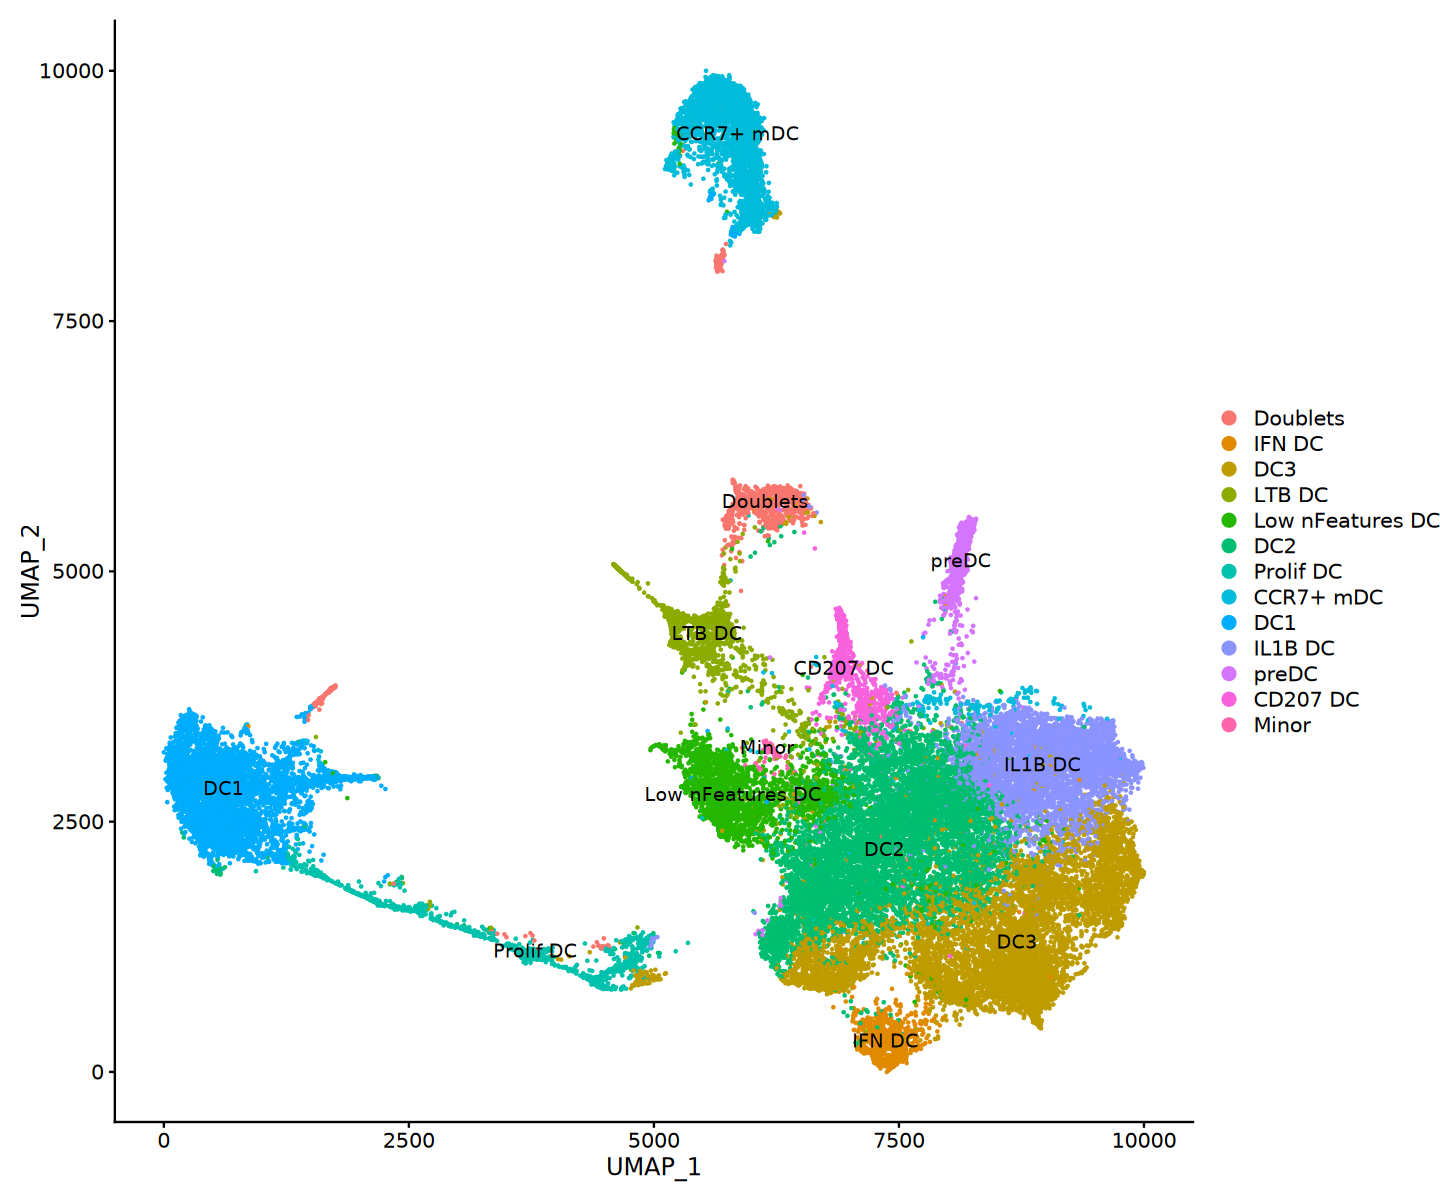

In [10]:
#Plot UMAP
options(repr.plot.height=10, repr.plot.width=12)
DimPlot(data, reduction = "umap", label=TRUE)

## Define our signatures (used top 100 genes):
* c2 and c4 has lots of small and negative lfc's, for these used only the degs with lfc > 0 and adj_p < 0.05
* for c2 this was 6 genes, for c4 this was 69 genes

In [11]:
c1 <- list(c('PLAUR','GPR183','NFKBIA','SRGN','FTH1','IER3','NEAT1','SAT1','SOD2','BTG1','IL1B','NAMPT','CREM','RGCC','CD83','NR4A3','ATP1B3','LMNA','REL','KDM6B','PPP1R15A','DUSP2','BCL2A1','NINJ1','OLR1','RGS1','INSIG1','G0S2','PNRC1','ID2','VEGFA','CD44','SAMSN1','HBEGF','MCL1','CD63','TNFAIP3','PIM3','NR4A2','NFE2L2','C15orf48','MAFF','CXCL2','MXD1','ZNF331','CCL3','FOSB','CDKN1A','GADD45B','CFLAR','EREG','NFKB1','SERPINB9','FOSL2','STX11','SOCS3','RPS17','TGIF1','SGK1','PDE4B','NFKBIZ','SDCBP','DUSP1','C1QA','GNA13','CD9','EIF1','AREG','ALOX5AP','ICAM1','CEBPB','CD14','MS4A7','RPS20','NPC2','CHMP1B','CSRNP1','JUNB','GLUL','GABARAPL1','CTSB','CXCR4','FCGR2A','C1QB','UPP1','TREM1','RPL13A','ZFAND5','MT-ND2','BIRC3','LITAF','DUSP4','CCL4','RILPL2','CXCL16','XBP1','RPL27A','ZFP36','MALAT1','RGS2'))
c2 <- list(c('RPLP1','RPL10','FTL','RPL19','RPS12','TMSB4X'))
c3 <- list(c('SIK3','ZFAND3','RAPGEF1','MED13L','JARID2','GAB2','XYLT1','ETV6','SIPA1L1','FOXN3','ARHGAP26','AKAP13','QKI','RABGEF1','TET2','ZSWIM6','NFAT5','MYO9B','ELMO1','GNA12','FNDC3B','PIK3R5','NFKB1','FAM49A','SNX9','CCSER1','SIPA1L3','SPAG9','MAP4K4','MALT1','FBXO11','RAB8B','GNA13','CYTH1','MCTP1','CDK14','DYRK1A','TRIO','ARIH1','ELF1','DENND5A','ANKRD11','MAP4K3','CHD2','MAML3','DENND4A','CHST11','BIRC6','CMIP','PRKCE','TEX14','TRAF3','PDE4B','DPYD','FBXW7','KDM2A','LDLRAD4','ABR','KMT2C','ARID1B','MANBA','PTK2B','KDM6A','GPCPD1','CTNNB1','MIR181A1HG','PPP6R3','FNBP1','BRAF','OXSR1','EMILIN2','FOXO3','ANKHD1','TCF12','NAMPT','EEF1G','TRAK1','LPP','STAG1','CAMK1D','PAN3','PFKFB3','ATP13A3','PLXDC2','BANP','EPB41L3','ZHX2','AMZ1','JMJD1C','RBM47','RFTN1','ESYT2','UBE2R2','PSME4','RCOR1','INPP5A','SMAD3','DENND1A','CDC42SE2','DIAPH2'))
c4 <- list(c('S100B','TMSB10','RPS19','GAPDH','LTB','HLA-DQB2','PFN1','ACTB','SERF2','TMSB4X','RPS15A','RPS3A','RPL14','AIF1','RPL28','RPS23','RPS13','RPS12','ACTG1','EEF1A1','RPS15','RPL41','RPL7A','RPL30','RPL19','RPL32','RPLP1','S100A11','RPS27A','RPS4X','SH3BGRL3','GSN','RPS3','RPL35','LST1','NACA','RPS25','RPL10','RPL15','PFDN5','ARPC3','CD1A','RPL11','RPL34','RPLP0','TUBA1B','ARHGDIB','FTL','PPIA','RPS28','RPS24','HINT1','LGALS1','MYL12A','RPS26','C15orf48','IL22RA2','PKIB','C1QC','VAMP8','SUMO2','NRN1','S100A2','TACSTD2','PPM1N','MTRNR2L8','RPS4Y1','HLA-DQA2','FCGBP'))
c5 <- list(c('FOS','RPS2','RPS29','CXCR4','RPS11','CEBPD','RPL27A','RPL21','RPL37A','TSC22D3','MT-ND4','RPL23','RPL13A','RPL7','RPS20','MNDA','CYBA','RPL38','MT-CO3','ARPC4','ZFP36L2','MT-ND2','SGK1','MALAT1','CHMP4A','MT-ND1','RPS27','DDX5','TXNIP','PHACTR1','RGS1','IFI16','RPL3','RPL35','TMBIM4','FOSB','PSMA1','STK17B','DUSP1','HLA-DMB','ALDH2','GNAI2','PSMA4','UBA52','NDUFB8','MT-CO1','RGS2','HLA-DRA','RPL10A','RPL9','P2RY13','FKBP5','NDUFB1','NDUFC2','MZT2B','TRA2B','EIF3E','SRSF9','CORO1A','MT-ND3','EFHD2','ARF6','MT-ATP6','FAM89B','PLEKHO1','CD48','RPS18','SNRPE','JUNB','FGL2','AREG','IER2','DPYSL2','RPLP2','JUND','RPL23A','PNISR','EVI2B','COPE','IGSF6','GNAS','RPL15','SRSF5','HERPUD1','HNRNPD','JUN','ANXA1','COMMD3','BRI3','EIF2S2','CD69','GMFG','SMAP2','RPS6','VAMP2','KLF6','LYZ','KLF4','SERBP1','MT-CYB'))
c6 <- list(c('SAMHD1','TXNIP','IFITM2','MS4A6A','CD1D','CD72','IFITM3','POU2F2','MEF2C','PALLD','IFI16','SCIMP','CCR1','XAF1','KCNK6','SP110','CCDC50','MYD88','CLEC10A','CST3','LIMD2','KCTD12','MX1','OAS1','TNFAIP8L2','HIST1H4C','GAPT','GLIPR1','LRRC25','NAGK','PPP1R14A','CD180','GAS6','GCA','CSK','LSP1','CAT','RPL37','ADD3','NAIP','TRIM38','ITGAM','IFITM1','SAMD9','PRMT2','MRC1','SELL','FCGR2B','CNN2','CD2','MBNL1','KIAA0930','ATM','TRAF3IP3','CD37','MIS18BP1','C1orf162','CIITA','ITGA4','STX7','CX3CR1','TMEM154','RGS18','MX2','PLD4','FGD2','TNFSF10','SPINT2','UCP2','MS4A4E','LY6E','CD302','APPL1','PHYKPL','PTPRC','PARP9','PNISR','NCKAP1L','PRAM1','IFI6','WAS','SAMD9L','RPS8','RNASE6','FGL2','CCDC88A','STARD7','IL17RA','PAK1','JAK3','CRTAP','TRIM22','HCLS1','BST2','ARHGAP30','IFI44L','SPOP','ANAPC16','LBR','DDX17'))
c7 <- list(c('MT-ND4L','CD74','GABARAP','ATP6V0C','PFN1','PPIA','SYNGR2','ACTB','RPLP0','NME2','MT-ATP8','ARF5','GAPDH','MIF','POLD4','GNG5','PCBP2','PPDPF','RHOA','SH3BGRL3','PPIB','PSMA6','CDKN1A','GRINA','ZYX','GNG10','ZFP36','RPS13','TPI1','PSMB10','HLA-DRB5','ALDOA','MAN2B1','RAB24','CNN2','ACTG1','COX5A','RNASEK','SERF2','NAPSA','TAGLN2','DAZAP2','PEA15','COX6A1','RHOG','TMSB10','S100A10','PSME1','IGFLR1','SNRPD2','HSPB1','RPL30','CFL1','PRR13','RPL8','SEC61B','COX8A','RPS7','HSPA8','SPI1','RPL28','TNFSF13','NR4A1','IFITM1','RPS26','EMD','HIGD2A','CDC37','CST3','POLR2E','NAPA','NDUFA6','CHCHD2','FKBP1A','SLC25A5','OTUB1','H3F3B','WDR83OS','FAU','KRTCAP2','LSP1','UCP2','APH1A','RPL29','FXYD5','EEF1A1','HMGN4','RPS21','TYROBP','PHB2','MTHFD2','MYL6','NDUFB11','HSPE1','SEC13','CLIC1','DNAJB1','IFITM3','H2AFZ','PKM'))
c8 <- list(c('S100B','IL18','CLNK','BASP1','STK17A','PKIB','LTB','CD1A','CD1E','PTPRC','PAK1','CCND1','GNAS','PLAC8','JUND','GPR82','GNAI2','NDRG2','ENTPD1','BOD1L1','FAM89B','PARM1','PSTPIP2','PLEKHO1','PTMS','HPGDS','FILIP1L','AFF3','PPA1','VASP','FUT8','SCPEP1','SMCO4','DDX5','RUNX3','YWHAH','CEACAM3','CYBB','HERPUD1','SRSF7','METRNL','KCNMB1','CCR6','MS4A6A','PLXNC1','PIK3R6','TLN1','BTG2','SUSD3','HIP1','MYCBP2','TLR10','GCC2','STK17B','P2RY13','GAPT','LST1','OGFRL1','TACSTD2','ACTR3','IGSF6','G3BP2','H2AFY','NCL','ARHGAP22','GNAO1','NABP1','MTDH','MT-ND3','PALLD','GAB3','DEGS1','SAMHD1','ICAM3','RPS6KA3','DDX17','TAF10','SKIL','LCP1','MBP','ABI3','SLC8A1','ITGAX','DENND1B','ARHGAP5','DOCK10','GRASP','GTF2I','PPP1R14B','ZNF791','TXNIP','MACF1','IFNGR1','TSC22D3','SKAP2','PLCG2','ARF6','BCO2','TMEM131','CD1C'))
c9 <- list(c('LTB','MYL12A','IL22RA2','SUSD3','ACTG1','S100B','CD1A','PKIB','RPS19','ABI3','PRR13','PSMB9','HCK','SMCO4','KCNMB1','GDI2','SYNGR2','PAK1','PLAC8','COTL1','TAP1','CFL1','PFN1','LST1','CA2','CORO1A','DBI','GSN','ACTB','RUNX3','FXYD5','TMSB10','GNGT2','VASP','SMAGP','RPL36AL','ACTR3','SCPEP1','SIGLEC10','HINT1','SUB1','SPINT2','SPI1','NKG7','GCA','PRDX5','IL18','ITGB7','MYL9','UCP2','NDRG2','PFDN5','ERCC1','RGS19','SNAP29','NPM1','CNN2','COX5A','LDHB','PYCARD','PPA1','SUMO2','TPI1','PDGFRB','LAMTOR1','PPM1J','SLC25A5','PTMS','ARPC2','PRELID1','ENTPD1','GNAO1','RPL14','TMEM14B','OAZ1','UFC1','PFDN2','FDFT1','UBL5','CDK2AP2','ARPC3','SPCS1','ZNF385A','ARPC5','PIK3R6','SNRPG','NME4','TRAPPC1','AIF1','RPS5','LCP1','MYL12B','CAPZB','SLC38A1','MLF2','ARHGAP9','GPR82','G3BP2','SMDT1','DEGS1'))
c10 <- list(c('HMGB1','STMN1','H2AFZ','MKI67','TUBB','HMGB2','TUBA1B','TYMS','CENPF','CD1A','CKS1B','CDK1','UBE2C','HIST1H4C','NUSAP1','SMC4','DUT','HMGN2','RPA3','TOP2A','DEK','H2AFV','TK1','PTMA','CARHSP1','ZWINT','BIRC5','CENPM','SIVA1','AURKB','S100B','TMEM106C','IDH2','H2AFX','CDCA3','DTYMK','RRM2','RANBP1','RAD51AP1','CDKN3','RUNX3','MAD2L1','CENPW','UBE2T','ANP32E','WDR34','NUDT1','RAN','TPX2','CENPK','CLSPN','SMC2','PA2G4','NUCKS1','LMNB1','TACSTD2','ANP32B','ATAD2','TMPO','PHF19','SKA2','ASPM','CHCHD2','ESCO2','DNMT1','FCGBP','BARD1','RRM1','CKS2','NDC80','NCAPG','PTGES3','CEP55','MCM7','USP1','KIFC1','GMNN','FAM111A','IL22RA2','GTSE1','SNRPD1','RBBP7','BRCA1','EZH2','CCNA2','CDCA5','HMGB3','PCNA','NUF2','SNRPG','HPGDS','NCAPH','HPRT1','PSMC3','KIF23','ASF1B','PLEK2','CENPU','DHFR','CTNND1'))